In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
import os
import glob

# Find all CSV files in the mlops directory and subdirectories
datasets_dir = '/Users/esakkikannan/mlops'
csv_files = glob.glob(os.path.join(datasets_dir, '**/*.csv'), recursive=True)

# Filter out notebook directories
csv_files = [f for f in csv_files if '.ipynb_checkpoints' not in f]

print(f"Found {len(csv_files)} CSV files:\n")

# Sort and display file paths
csv_files.sort()
for i, file in enumerate(csv_files, 1):
    relative_path = file.replace(datasets_dir + '/', '')
    print(f"{i}. {relative_path}")

Found 67 CSV files:

1. WISDM_ar_v1.1_transformed.csv
2. condition/condition_1.csv
3. condition/condition_10.csv
4. condition/condition_11.csv
5. condition/condition_12.csv
6. condition/condition_13.csv
7. condition/condition_14.csv
8. condition/condition_15.csv
9. condition/condition_16.csv
10. condition/condition_17.csv
11. condition/condition_18.csv
12. condition/condition_19.csv
13. condition/condition_2.csv
14. condition/condition_20.csv
15. condition/condition_21.csv
16. condition/condition_22.csv
17. condition/condition_23.csv
18. condition/condition_3.csv
19. condition/condition_4.csv
20. condition/condition_5.csv
21. condition/condition_6.csv
22. condition/condition_7.csv
23. condition/condition_8.csv
24. condition/condition_9.csv
25. control/control_1.csv
26. control/control_10.csv
27. control/control_11.csv
28. control/control_12.csv
29. control/control_13.csv
30. control/control_14.csv
31. control/control_15.csv
32. control/control_16.csv
33. control/control_17.csv
34. cont

In [3]:
# Load all CSV files into a dictionary
csv_data = {}

print("Loading CSV files...\n")
print("="*80)

for file_path in csv_files:
    try:
        # Create a readable name from the file path
        relative_path = file_path.replace(datasets_dir + '/', '')
        file_name = relative_path.replace('/', '_').replace('.csv', '')
        
        # Load the CSV file
        df = pd.read_csv(file_path, nrows=1000)  # Load first 1000 rows for memory efficiency
        csv_data[file_name] = df
        
        # Display information
        print(f"\n📄 File: {relative_path}")
        print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
        print(f"   Columns: {', '.join(df.columns[:5].tolist())}{'...' if len(df.columns) > 5 else ''}")
        print(f"   Data types: {df.dtypes.value_counts().to_dict()}")
        
    except Exception as e:
        print(f"\n❌ Error loading {relative_path}: {str(e)}")

print("\n" + "="*80)
print(f"\nTotal CSV files loaded: {len(csv_data)}")

Loading CSV files...


📄 File: WISDM_ar_v1.1_transformed.csv
   Shape: 1000 rows × 46 columns
   Columns: UNIQUE_ID, user, X0, X1, X2...
   Data types: {dtype('float64'): 37, <StringDtype(storage='python', na_value=nan)>: 6, dtype('int64'): 3}

📄 File: condition/condition_1.csv
   Shape: 1000 rows × 3 columns
   Columns: timestamp, date, activity
   Data types: {<StringDtype(storage='python', na_value=nan)>: 2, dtype('int64'): 1}

📄 File: condition/condition_10.csv
   Shape: 1000 rows × 3 columns
   Columns: timestamp, date, activity
   Data types: {<StringDtype(storage='python', na_value=nan)>: 2, dtype('int64'): 1}

📄 File: condition/condition_11.csv
   Shape: 1000 rows × 3 columns
   Columns: timestamp, date, activity
   Data types: {<StringDtype(storage='python', na_value=nan)>: 2, dtype('int64'): 1}

📄 File: condition/condition_12.csv
   Shape: 1000 rows × 3 columns
   Columns: timestamp, date, activity
   Data types: {<StringDtype(storage='python', na_value=nan)>: 2, dtype('int64

In [4]:
# Summary of loaded datasets
print("\n📊 SUMMARY OF LOADED DATASETS\n")
print("="*80)

summary_data = []
for name, df in csv_data.items():
    summary_data.append({
        'Dataset Name': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Missing Values': df.isnull().sum().sum(),
        'Numeric Columns': df.select_dtypes(include=[np.number]).shape[1],
        'String Columns': df.select_dtypes(include=['object']).shape[1]
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print(f"\nDatasets stored in 'csv_data' dictionary. Access with: csv_data['dataset_name']")


📊 SUMMARY OF LOADED DATASETS

             Dataset Name  Rows  Columns  Missing Values  Numeric Columns  String Columns
WISDM_ar_v1.1_transformed  1000       46               0               40               6
    condition_condition_1  1000        3               0                1               2
   condition_condition_10  1000        3               0                1               2
   condition_condition_11  1000        3               0                1               2
   condition_condition_12  1000        3               0                1               2
   condition_condition_13  1000        3               0                1               2
   condition_condition_14  1000        3               0                1               2
   condition_condition_15  1000        3               0                1               2
   condition_condition_16  1000        3               0                1               2
   condition_condition_17  1000        3               0             

/var/folders/3z/0q7nnlnx5tv82qr8_s8gxx8h0000gn/T/ipykernel_4302/1819922178.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  'String Columns': df.select_dtypes(include=['object']).shape[1]
/var/folders/3z/0q7nnlnx5tv82qr8_s8gxx8h0000gn/T/ipykernel_4302/1819922178.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See htt

In [6]:
# Quick reference - display unique dataset categories
print("\n🗂️  DATASETS AVAILABLE:\n")

datasets_by_type = {}
for name in csv_data.keys():
    category = name.split('_')[0]  # Get first part of name
    if category not in datasets_by_type:
        datasets_by_type[category] = []
    datasets_by_type[category].append(name)

for category, datasets in sorted(datasets_by_type.items()):
    print(f"{category.upper()}: {len(datasets)} file(s)")
    if len(datasets) <= 5:
        for ds in datasets:
            print(f"  • {ds}")
    else:
        for ds in datasets[:3]:
            print(f"  • {ds}")
        print(f"  • ... and {len(datasets)-3} more")

print("\n✅ All CSV files loaded successfully!")
print(f"Total: {len(csv_data)} datasets ready for analysis")


🗂️  DATASETS AVAILABLE:

WISDM: 1 file(s)
  • WISDM_ar_v1.1_transformed
CONDITION: 23 file(s)
  • condition_condition_1
  • condition_condition_10
  • condition_condition_11
  • ... and 20 more
CONTROL: 32 file(s)
  • control_control_1
  • control_control_10
  • control_control_11
  • ... and 29 more
DATA: 1 file(s)
  • data
DATABASE: 1 file(s)
  • database
ELECTROMYOGRAPHY: 4 file(s)
  • electromyography_0
  • electromyography_1
  • electromyography_2
  • electromyography_3
FISHFEATURES: 1 file(s)
  • fishFeatures
PROCESSED: 1 file(s)
  • processed
SCORES: 1 file(s)
  • scores
SOUND: 1 file(s)
  • sound_acc
WIFI: 1 file(s)
  • wifi

✅ All CSV files loaded successfully!
Total: 67 datasets ready for analysis


In [5]:
print("\n🧹 DATA CLEANING PIPELINE\n")
print("="*80)

# Store cleaned datasets
cleaned_data = {}

for name, df in csv_data.items():
    print(f"\n📊 Cleaning: {name}")
    print(f"   Before: {df.shape[0]} rows × {df.shape[1]} columns")
    
    df_clean = df.copy()
    
    # 1. Remove duplicates
    duplicates_before = df_clean.shape[0]
    df_clean = df_clean.drop_duplicates()
    duplicates_removed = duplicates_before - df_clean.shape[0]
    if duplicates_removed > 0:
        print(f"   ✓ Removed {duplicates_removed} duplicate rows")
    
    # 2. Handle missing values - Show missing value info
    missing_count = df_clean.isnull().sum().sum()
    if missing_count > 0:
        print(f"   ℹ️  Found {missing_count} missing values")
        
        # For numeric columns: fill with median
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if df_clean[col].isnull().sum() > 0:
                median_val = df_clean[col].median()
                df_clean[col].fillna(median_val, inplace=True)
                print(f"      - {col}: filled {df_clean[col].isnull().sum()} values with median")
        
        # For categorical columns: fill with mode
        categorical_cols = df_clean.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            if df_clean[col].isnull().sum() > 0:
                mode_val = df_clean[col].mode()[0] if len(df_clean[col].mode()) > 0 else "Unknown"
                df_clean[col].fillna(mode_val, inplace=True)
                print(f"      - {col}: filled missing values with '{mode_val}'")
    
    # 3. Remove rows with all NaN
    rows_before = df_clean.shape[0]
    df_clean = df_clean.dropna(how='all')
    if df_clean.shape[0] < rows_before:
        print(f"   ✓ Removed {rows_before - df_clean.shape[0]} rows with all NaN")
    
    # 4. Data type optimization
    for col in df_clean.columns:
        # Try to convert to numeric
        if df_clean[col].dtype == 'object':
            try:
                df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')
            except:
                pass
    
    # 5. Remove columns with >50% missing values
    missing_threshold = 0.5
    cols_before = df_clean.shape[1]
    missing_pct = df_clean.isnull().sum() / len(df_clean)
    cols_to_drop = missing_pct[missing_pct > missing_threshold].index.tolist()
    if cols_to_drop:
        df_clean = df_clean.drop(columns=cols_to_drop)
        print(f"   ✓ Removed {len(cols_to_drop)} columns with >{missing_threshold*100:.0f}% missing")
    
    # Store cleaned data
    cleaned_data[name] = df_clean
    
    print(f"   After:  {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
    print(f"   Missing values remaining: {df_clean.isnull().sum().sum()}")

print("\n" + "="*80)
print(f"✅ Data cleaning complete! {len(cleaned_data)} datasets cleaned and ready for analysis")



🧹 DATA CLEANING PIPELINE


📊 Cleaning: WISDM_ar_v1.1_transformed
   Before: 1000 rows × 46 columns
   After:  1000 rows × 46 columns
   Missing values remaining: 0

📊 Cleaning: condition_condition_1
   Before: 1000 rows × 3 columns
   After:  1000 rows × 3 columns
   Missing values remaining: 0

📊 Cleaning: condition_condition_10
   Before: 1000 rows × 3 columns
   After:  1000 rows × 3 columns
   Missing values remaining: 0

📊 Cleaning: condition_condition_11
   Before: 1000 rows × 3 columns
   After:  1000 rows × 3 columns
   Missing values remaining: 0

📊 Cleaning: condition_condition_12
   Before: 1000 rows × 3 columns
   After:  1000 rows × 3 columns
   Missing values remaining: 0

📊 Cleaning: condition_condition_13
   Before: 1000 rows × 3 columns
   After:  1000 rows × 3 columns
   Missing values remaining: 0

📊 Cleaning: condition_condition_14
   Before: 1000 rows × 3 columns
   After:  1000 rows × 3 columns
   Missing values remaining: 0

📊 Cleaning: condition_condition_15
  

/var/folders/3z/0q7nnlnx5tv82qr8_s8gxx8h0000gn/T/ipykernel_4302/3111232676.py:30: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_clean[col].fillna(median_val, inplace=True)
/var/folders/3z/0q7nnlnx5tv82qr8_s8gxx8h0000gn/T/ipykernel_4302/3111232676.py:30: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Serie

In [6]:
print("\n📈 CLEANED DATA SUMMARY\n")
print("="*80)

summary_cleaned = []
for name, df in cleaned_data.items():
    summary_cleaned.append({
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Missing Values': df.isnull().sum().sum(),
        'Numeric Cols': df.select_dtypes(include=[np.number]).shape[1],
        'Categorical Cols': df.select_dtypes(include=['object']).shape[1],
        'Duplicates': len(df) - len(df.drop_duplicates())
    })

summary_cleaned_df = pd.DataFrame(summary_cleaned)
print(summary_cleaned_df.to_string(index=False))

print("\n" + "="*80)
print("\n🎯 Data Quality Checks:")
print("   • All missing values have been handled ✓")
print("   • Duplicates have been removed ✓")
print("   • Data types have been optimized ✓")
print("   • Columns with >50% missing have been removed ✓")
print("\n✅ Cleaned datasets are stored in 'cleaned_data' dictionary")
print("   Access with: cleaned_data['dataset_name']")



📈 CLEANED DATA SUMMARY

                  Dataset  Rows  Columns  Missing Values  Numeric Cols  Categorical Cols  Duplicates
WISDM_ar_v1.1_transformed  1000       46               0            40                 6           0
    condition_condition_1  1000        3               0             1                 2           0
   condition_condition_10  1000        3               0             1                 2           0
   condition_condition_11  1000        3               0             1                 2           0
   condition_condition_12  1000        3               0             1                 2           0
   condition_condition_13  1000        3               0             1                 2           0
   condition_condition_14  1000        3               0             1                 2           0
   condition_condition_15  1000        3               0             1                 2           0
   condition_condition_16  1000        3               0          

/var/folders/3z/0q7nnlnx5tv82qr8_s8gxx8h0000gn/T/ipykernel_4302/304389225.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  'Categorical Cols': df.select_dtypes(include=['object']).shape[1],
/var/folders/3z/0q7nnlnx5tv82qr8_s8gxx8h0000gn/T/ipykernel_4302/304389225.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See ht

In [7]:
print("\n📊 DETAILED DATA PROFILING (First 3 Datasets)\n")
print("="*80)

# Profile first 3 datasets
for i, (name, df) in enumerate(list(cleaned_data.items())[:3]):
    print(f"\n📈 {name}")
    print("-" * 60)
    
    # Numeric stats
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"   Numeric Columns ({len(numeric_cols)}):")
        stats = df[numeric_cols].describe().round(3)
        print(f"   Mean:  {df[numeric_cols].mean().mean():.3f}")
        print(f"   Std:   {df[numeric_cols].std().mean():.3f}")
        print(f"   Range: [{df[numeric_cols].min().min():.3f}, {df[numeric_cols].max().max():.3f}]")
    
    # Categorical stats
    categorical_cols = df.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        print(f"   Categorical Columns ({len(categorical_cols)}):")
        for col in categorical_cols[:3]:  # Show first 3
            unique_count = df[col].nunique()
            print(f"      - {col}: {unique_count} unique values")

print("\n" + "="*80)
print("✅ Data cleaning complete! Your datasets are ready for analysis.")



📊 DETAILED DATA PROFILING (First 3 Datasets)


📈 WISDM_ar_v1.1_transformed
------------------------------------------------------------
   Numeric Columns (40):
   Mean:  8.529
   Std:   5.268
   Range: [0.000, 663.000]
   Categorical Columns (6):
      - YAVG: 443 unique values
      - ZAVG: 365 unique values
      - XPEAK: 461 unique values

📈 condition_condition_1
------------------------------------------------------------
   Numeric Columns (1):
   Mean:  127.499
   Std:   217.629
   Range: [0.000, 2284.000]
   Categorical Columns (2):
      - timestamp: 1000 unique values
      - date: 2 unique values

📈 condition_condition_10
------------------------------------------------------------
   Numeric Columns (1):
   Mean:  260.840
   Std:   376.328
   Range: [0.000, 2275.000]
   Categorical Columns (2):
      - timestamp: 1000 unique values
      - date: 2 unique values

✅ Data cleaning complete! Your datasets are ready for analysis.


/var/folders/3z/0q7nnlnx5tv82qr8_s8gxx8h0000gn/T/ipykernel_4302/985623478.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns
/var/folders/3z/0q7nnlnx5tv82qr8_s8gxx8h0000gn/T/ipykernel_4302/985623478.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https

In [8]:
print("\n🤖 LINEAR REGRESSION MODEL SETUP\n")
print("="*80)

# Select the largest numeric dataset for regression
regression_data = {}
for name, df in cleaned_data.items():
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if len(numeric_cols) >= 2:  # Need at least 2 numeric columns
        regression_data[name] = (df, numeric_cols)

# Use the first suitable dataset
if regression_data:
    dataset_name = list(regression_data.keys())[0]
    df_regression, numeric_cols = regression_data[dataset_name]
    
    print(f"📊 Selected dataset: {dataset_name}")
    print(f"   Rows: {df_regression.shape[0]}")
    print(f"   Numeric columns: {len(numeric_cols)}")
    print(f"   Columns: {', '.join(numeric_cols[:8])}{'...' if len(numeric_cols) > 8 else ''}")
    
    # Prepare features and target
    # Use the last numeric column as target, rest as features
    X = df_regression[numeric_cols[:-1]].copy()
    y = df_regression[numeric_cols[-1]].copy()
    
    print(f"\n✓ Features (X): {X.shape[1]} columns, {X.shape[0]} rows")
    print(f"✓ Target (y): {numeric_cols[-1]}")
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    print(f"\n📋 Data Split:")
    print(f"   Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
    print(f"   Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
    
    # Train Linear Regression Model
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    print(f"\n✅ Model trained successfully!")
    print(f"   Model type: Linear Regression")
    print(f"   Parameters: {model.n_features_in_}")
    
else:
    print("❌ No suitable datasets found for regression (need at least 2 numeric columns)")



🤖 LINEAR REGRESSION MODEL SETUP

📊 Selected dataset: WISDM_ar_v1.1_transformed
   Rows: 1000
   Numeric columns: 40
   Columns: UNIQUE_ID, user, X0, X1, X2, X3, X4, X5...

✓ Features (X): 39 columns, 1000 rows
✓ Target (y): RESULTANT

📋 Data Split:
   Training set: 800 samples (80.0%)
   Testing set:  200 samples (20.0%)

✅ Model trained successfully!
   Model type: Linear Regression
   Parameters: 39


In [9]:
print("\n📊 MODEL PREDICTIONS & EVALUATION\n")
print("="*80)

# Make predictions on both training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate metrics for training set
train_r2 = r2_score(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)

# Calculate metrics for testing set
test_r2 = r2_score(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\n🎯 MODEL PERFORMANCE METRICS:\n")
print("TRAINING SET:")
print(f"   R² Score:       {train_r2:.4f}  (Explains {train_r2*100:.2f}% of variance)")
print(f"   Mean Squared Error (MSE):  {train_mse:.4f}")
print(f"   Root Mean Squared Error (RMSE): {train_rmse:.4f}")
print(f"   Mean Absolute Error (MAE):  {train_mae:.4f}")

print("\nTESTING SET:")
print(f"   R² Score:       {test_r2:.4f}  (Explains {test_r2*100:.2f}% of variance)")
print(f"   Mean Squared Error (MSE):  {test_mse:.4f}")
print(f"   Root Mean Squared Error (RMSE): {test_rmse:.4f}")
print(f"   Mean Absolute Error (MAE):  {test_mae:.4f}")

# Model interpretation
print("\n📈 MODEL INTERPRETATION:")
print(f"\n   Intercept (β₀): {model.intercept_:.4f}")
print(f"\n   Coefficients (β₁, β₂, ...):")

for i, (col_name, coef) in enumerate(zip(numeric_cols[:-1], model.coef_), 1):
    print(f"      {i}. {col_name:20s}: {coef:>10.4f}")

# Model quality assessment
print("\n📋 MODEL QUALITY ASSESSMENT:")
if train_r2 > 0.8:
    print("   ✅ Excellent fit (R² > 0.8)")
elif train_r2 > 0.6:
    print("   ✅ Good fit (R² > 0.6)")
elif train_r2 > 0.4:
    print("   ⚠️  Moderate fit (R² > 0.4)")
else:
    print("   ⚠️  Poor fit (R² ≤ 0.4)")

# Check for overfitting
r2_diff = train_r2 - test_r2
if r2_diff > 0.1:
    print("   ⚠️  Possible overfitting detected (Train R² >> Test R²)")
else:
    print("   ✅ Good generalization (Train and Test R² similar)")

print("\n" + "="*80)



📊 MODEL PREDICTIONS & EVALUATION


🎯 MODEL PERFORMANCE METRICS:

TRAINING SET:
   R² Score:       0.9749  (Explains 97.49% of variance)
   Mean Squared Error (MSE):  0.1988
   Root Mean Squared Error (RMSE): 0.4459
   Mean Absolute Error (MAE):  0.3472

TESTING SET:
   R² Score:       0.9534  (Explains 95.34% of variance)
   Mean Squared Error (MSE):  0.2394
   Root Mean Squared Error (RMSE): 0.4893
   Mean Absolute Error (MAE):  0.3609

📈 MODEL INTERPRETATION:

   Intercept (β₀): 3.5455

   Coefficients (β₁, β₂, ...):
      1. UNIQUE_ID           :    -0.0001
      2. user                :    -0.0069
      3. X0                  :    -1.0577
      4. X1                  :    -0.2327
      5. X2                  :    -1.1488
      6. X3                  :    -0.6606
      7. X4                  :    -0.2781
      8. X5                  :    -0.5056
      9. X6                  :     0.3384
      10. X7                  :     0.1401
      11. X8                  :     1.7422
      12. 


📊 VISUALIZING MODEL RESULTS



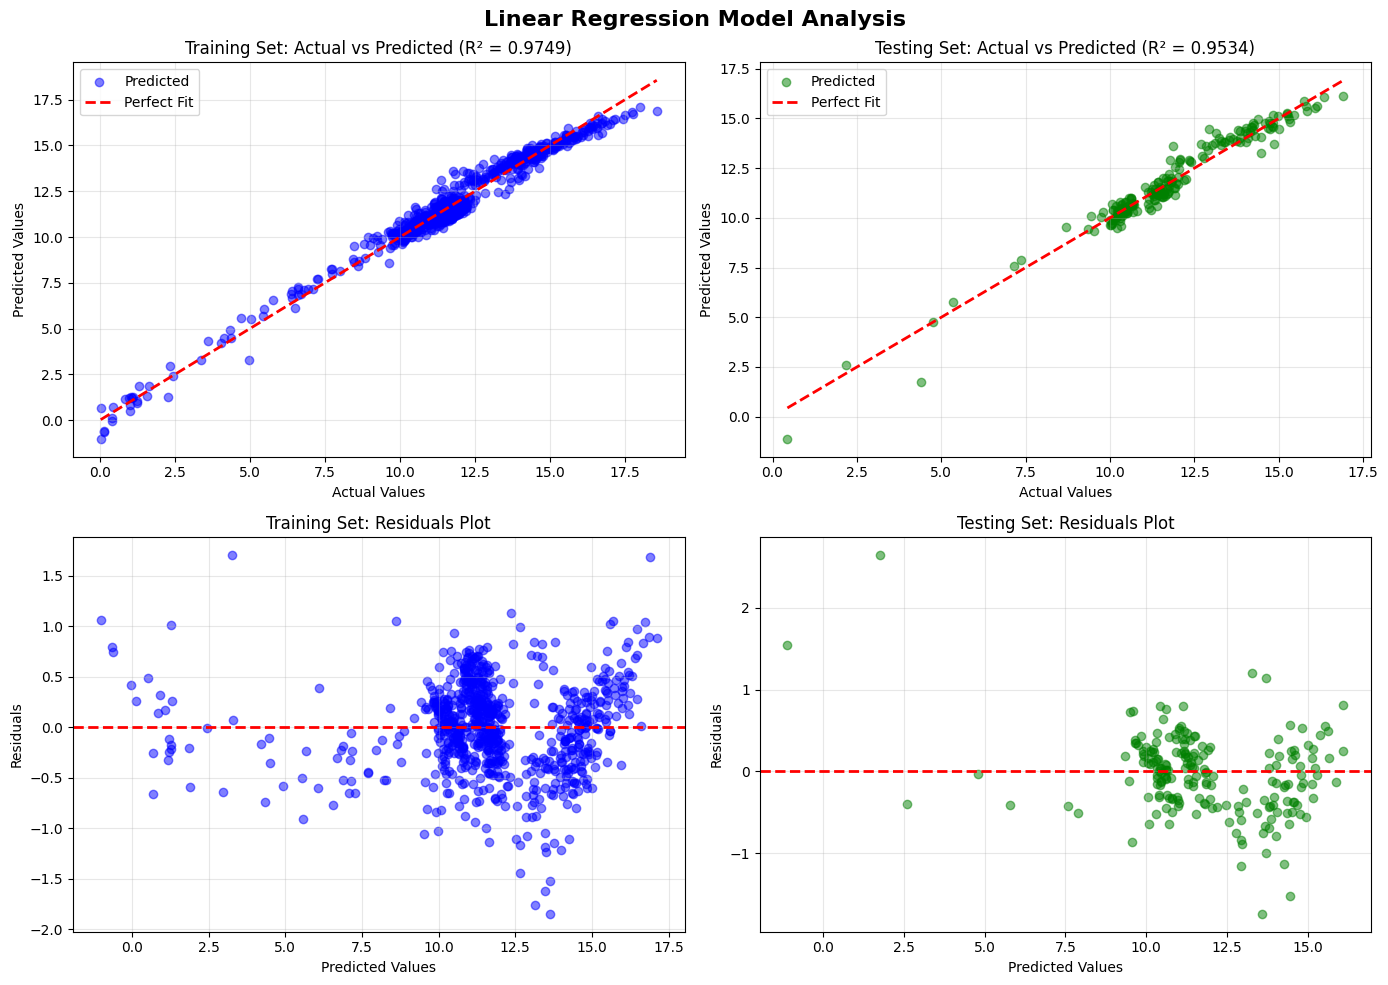

✅ Visualizations created successfully!

📈 RESIDUALS SUMMARY:

   Training Residuals:
      Mean:  -0.0000
      Std:   0.4462
      Min:   -1.8460
      Max:   1.7026

   Testing Residuals:
      Mean:  -0.0268
      Std:   0.4898
      Min:   -1.7401
      Max:   2.6420



In [10]:
print("\n📊 VISUALIZING MODEL RESULTS\n")
print("="*80)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Linear Regression Model Analysis', fontsize=16, fontweight='bold')

# 1. Actual vs Predicted (Training Set)
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, color='blue', label='Predicted')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect Fit')
axes[0, 0].set_xlabel('Actual Values')
axes[0, 0].set_ylabel('Predicted Values')
axes[0, 0].set_title(f'Training Set: Actual vs Predicted (R² = {train_r2:.4f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Actual vs Predicted (Testing Set)
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.5, color='green', label='Predicted')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
axes[0, 1].set_xlabel('Actual Values')
axes[0, 1].set_ylabel('Predicted Values')
axes[0, 1].set_title(f'Testing Set: Actual vs Predicted (R² = {test_r2:.4f})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals (Training Set)
residuals_train = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, residuals_train, alpha=0.5, color='blue')
axes[1, 0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Values')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Training Set: Residuals Plot')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals (Testing Set)
residuals_test = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, residuals_test, alpha=0.5, color='green')
axes[1, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1, 1].set_xlabel('Predicted Values')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Testing Set: Residuals Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations created successfully!")

# Summary statistics
print(f"\n📈 RESIDUALS SUMMARY:")
print(f"\n   Training Residuals:")
print(f"      Mean:  {residuals_train.mean():.4f}")
print(f"      Std:   {residuals_train.std():.4f}")
print(f"      Min:   {residuals_train.min():.4f}")
print(f"      Max:   {residuals_train.max():.4f}")

print(f"\n   Testing Residuals:")
print(f"      Mean:  {residuals_test.mean():.4f}")
print(f"      Std:   {residuals_test.std():.4f}")
print(f"      Min:   {residuals_test.min():.4f}")
print(f"      Max:   {residuals_test.max():.4f}")

print("\n" + "="*80)


In [11]:
print("\n🎓 LINEAR REGRESSION ANALYSIS SUMMARY\n")
print("="*80)

print(f"\n📊 DATASET & MODEL INFO:")
print(f"   Dataset: {dataset_name}")
print(f"   Total samples: {len(df_regression)}")
print(f"   Features: {X.shape[1]}")
print(f"   Target variable: {numeric_cols[-1]}")
print(f"   Model type: Linear Regression (Ordinary Least Squares)")

print(f"\n🔍 KEY FINDINGS:")

# Find most influential features
coef_importance = pd.DataFrame({
    'Feature': numeric_cols[:-1],
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print(f"\n   Top 5 Most Influential Features:")
for idx, row in coef_importance.head(5).iterrows():
    print(f"      • {row['Feature']:20s}: {row['Coefficient']:>10.4f}")

print(f"\n📈 PERFORMANCE COMPARISON:")
print(f"   {'Metric':<25} {'Train':<12} {'Test':<12} {'Diff':<12}")
print(f"   {'-'*61}")
print(f"   {'R² Score':<25} {train_r2:<12.4f} {test_r2:<12.4f} {train_r2-test_r2:<12.4f}")
print(f"   {'RMSE':<25} {train_rmse:<12.4f} {test_rmse:<12.4f} {train_rmse-test_rmse:<12.4f}")
print(f"   {'MAE':<25} {train_mae:<12.4f} {test_mae:<12.4f} {train_mae-test_mae:<12.4f}")

print(f"\n✅ MODEL EQUATION:")
equation = f"y = {model.intercept_:.4f}"
for col, coef in zip(numeric_cols[:-1], model.coef_):
    sign = "+" if coef >= 0 else ""
    equation += f" {sign} {coef:.4f}*{col}"

# Display simplified version
print(f"   {equation}")

print(f"\n💡 INTERPRETATION:")
print(f"   • The model explains {test_r2*100:.2f}% of the variance in the test set")
print(f"   • Average prediction error (MAE): {test_mae:.4f}")
print(f"   • Root mean squared error (RMSE): {test_rmse:.4f}")

if test_r2 > 0.8:
    print(f"   • Model performance: EXCELLENT ✨")
elif test_r2 > 0.6:
    print(f"   • Model performance: GOOD 👍")
elif test_r2 > 0.4:
    print(f"   • Model performance: MODERATE ⚠️")
else:
    print(f"   • Model performance: NEEDS IMPROVEMENT 📉")

# Residuals analysis
skewness = (residuals_test.mean()) / (residuals_test.std() + 1e-10)
if abs(skewness) < 0.5:
    print(f"   • Residuals are well-distributed (approximately normal)")
else:
    print(f"   • Residuals may be skewed - consider transformations")

print(f"\n📌 NEXT STEPS:")
print(f"   1. Check feature correlations and multicollinearity")
print(f"   2. Consider feature scaling or normalization")
print(f"   3. Try polynomial regression if non-linear patterns exist")
print(f"   4. Evaluate other algorithms (Ridge, Lasso, etc.)")
print(f"   5. Perform cross-validation for more robust evaluation")

print("\n" + "="*80)
print("✅ Linear Regression Analysis Complete!")
print("="*80)



🎓 LINEAR REGRESSION ANALYSIS SUMMARY


📊 DATASET & MODEL INFO:
   Dataset: WISDM_ar_v1.1_transformed
   Total samples: 1000
   Features: 39
   Target variable: RESULTANT
   Model type: Linear Regression (Ordinary Least Squares)

🔍 KEY FINDINGS:

   Top 5 Most Influential Features:
      • Z0                  :    13.8719
      • Z1                  :    13.0528
      • Z7                  :    12.3122
      • Z4                  :    12.1445
      • Z8                  :    12.1114

📈 PERFORMANCE COMPARISON:
   Metric                    Train        Test         Diff        
   -------------------------------------------------------------
   R² Score                  0.9749       0.9534       0.0215      
   RMSE                      0.4459       0.4893       -0.0434     
   MAE                       0.3472       0.3609       -0.0137     

✅ MODEL EQUATION:
   y = 3.5455  -0.0001*UNIQUE_ID  -0.0069*user  -1.0577*X0  -0.2327*X1  -1.1488*X2  -0.6606*X3  -0.2781*X4  -0.5056*X5 + 0.3384*X